In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from vizman import viz
import os
import re 

import pickle

%load_ext autoreload
%autoreload 2

from config import COLORS, COLOR_SCHEME, LABEL_MAP, gray_cmap, bone_white, half_black, emp_dataset_and_experiment_pairs

In [2]:
# Generate output folder
output_folder = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis")

input_folder = output_folder 

output_folder = output_folder / "04_metastability" 
output_folder.mkdir(exist_ok=True)


dataset_of_choice = "hcp_schaefer_100_dataset_gnm"
number_of_samples_each = 5

/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_52931/2436676723.py:40: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode="RGB")
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_52931/2436676723.py:54: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/2D_gradient.pdf


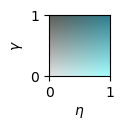

In [3]:
import numpy as np
from PIL import Image

from config import CORNERS_OF_2D_SPACE

# Hex codes
HEX_BOTTOM_LEFT  = CORNERS_OF_2D_SPACE["HEX_BOTTOM_LEFT"]
HEX_BOTTOM_RIGHT = CORNERS_OF_2D_SPACE["HEX_BOTTOM_RIGHT"]
HEX_TOP_LEFT     = CORNERS_OF_2D_SPACE["HEX_TOP_LEFT"]
HEX_TOP_RIGHT    = CORNERS_OF_2D_SPACE["HEX_TOP_RIGHT"]


def hex_to_rgb(hex_str):
    h = hex_str.lstrip("#")
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)], dtype=float)

bottom_left  = hex_to_rgb(HEX_BOTTOM_LEFT)
bottom_right = hex_to_rgb(HEX_BOTTOM_RIGHT)
top_left     = hex_to_rgb(HEX_TOP_LEFT)
top_right    = hex_to_rgb(HEX_TOP_RIGHT)

size = 256  # 256×256 pixel image

# Normalised coordinates: tx in [0,1] left→right, ty in [0,1] bottom→top
tx = np.linspace(0, 1, size)   # x axis
ty = np.linspace(0, 1, size)   # y axis (0 = bottom row in logical space)

TX, TY = np.meshgrid(tx, ty)   # shape (size, size)

# Bilinear interpolation across the four corners
# colour(tx, ty) = (1-ty)*[(1-tx)*BL + tx*BR] + ty*[(1-tx)*TL + tx*TR]
pixels = (
    (1 - TY)[..., None] * ((1 - TX)[..., None] * bottom_left  + TX[..., None] * bottom_right) +
         TY [..., None] * ((1 - TX)[..., None] * top_left     + TX[..., None] * top_right   )
)

# ty=0 is the bottom row logically, but row 0 in an image is the top → flip vertically
pixels = np.flipud(pixels).astype(np.uint8)

img = Image.fromarray(pixels, mode="RGB")



plt.figure(figsize=viz.cm_to_inch((2,2)))
plt.imshow(img)
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")
plt.xlim([0,255])
plt.ylim([0,255])

plt.xticks([0, 255], [0,1])
plt.yticks([0, 255], [0,1])

plt.tight_layout()
plt.savefig(output_folder / "2D_gradient.pdf", bbox_inches="tight", dpi=300)
print(output_folder / "2D_gradient.pdf")

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/2D_gradient_small.pdf


/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_52931/3560430724.py:40: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(pixels, mode="RGB")
/var/folders/b2/80yhhgwn2fjb5qv0cbj_cr6c0000gn/T/ipykernel_52931/3560430724.py:54: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


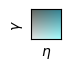

In [9]:
import numpy as np
from PIL import Image

from config import CORNERS_OF_2D_SPACE

# Hex codes
HEX_BOTTOM_LEFT  = CORNERS_OF_2D_SPACE["HEX_BOTTOM_LEFT"]
HEX_BOTTOM_RIGHT = CORNERS_OF_2D_SPACE["HEX_BOTTOM_RIGHT"]
HEX_TOP_LEFT     = CORNERS_OF_2D_SPACE["HEX_TOP_LEFT"]
HEX_TOP_RIGHT    = CORNERS_OF_2D_SPACE["HEX_TOP_RIGHT"]


def hex_to_rgb(hex_str):
    h = hex_str.lstrip("#")
    return np.array([int(h[i:i+2], 16) for i in (0, 2, 4)], dtype=float)

bottom_left  = hex_to_rgb(HEX_BOTTOM_LEFT)
bottom_right = hex_to_rgb(HEX_BOTTOM_RIGHT)
top_left     = hex_to_rgb(HEX_TOP_LEFT)
top_right    = hex_to_rgb(HEX_TOP_RIGHT)

size = 256  # 256×256 pixel image

# Normalised coordinates: tx in [0,1] left→right, ty in [0,1] bottom→top
tx = np.linspace(0, 1, size)   # x axis
ty = np.linspace(0, 1, size)   # y axis (0 = bottom row in logical space)

TX, TY = np.meshgrid(tx, ty)   # shape (size, size)

# Bilinear interpolation across the four corners
# colour(tx, ty) = (1-ty)*[(1-tx)*BL + tx*BR] + ty*[(1-tx)*TL + tx*TR]
pixels = (
    (1 - TY)[..., None] * ((1 - TX)[..., None] * bottom_left  + TX[..., None] * bottom_right) +
         TY [..., None] * ((1 - TX)[..., None] * top_left     + TX[..., None] * top_right   )
)

# ty=0 is the bottom row logically, but row 0 in an image is the top → flip vertically
pixels = np.flipud(pixels).astype(np.uint8)

img = Image.fromarray(pixels, mode="RGB")



plt.figure(figsize=viz.cm_to_inch((1,1)))
plt.imshow(img)
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\gamma$")
plt.xlim([0,255])
plt.ylim([0,255])

plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.savefig(output_folder / "2D_gradient_small.pdf", bbox_inches="tight", dpi=300)
print(output_folder / "2D_gradient_small.pdf")

In [4]:
# import matplotlib.patches as mpatches
# from matplotlib.legend_handler import HandlerBase
# import matplotlib.image as mpimg

# class HandlerGradient(HandlerBase):
#     def __init__(self, img_array):
#         self.img = img_array  # numpy RGB array (H, W, 3)
#         super().__init__()

#     def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
#         ax = legend.axes
#         # Place image in the patch slot
#         img_artist = ax.inset_axes(
#             [0, 0, 1, 1],
#             transform=trans,
#             bbox_transform=trans,
#             bbox_to_anchor=(xdescent, ydescent, width, height),
#         )
#         img_artist.imshow(self.img, aspect="auto", origin="upper")
#         img_artist.axis("off")
#         return [img_artist]

from matplotlib.legend_handler import HandlerBase
from matplotlib.image import BboxImage
from matplotlib.transforms import Bbox, TransformedBbox
import matplotlib.patches as mpatches

class HandlerGradient(HandlerBase):
    def __init__(self, img_array):
        self.img = img_array
        super().__init__()

    # def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
    #     bbox = Bbox.from_bounds(xdescent, ydescent, width, height)
    #     transformed_bbox = TransformedBbox(bbox, trans)
    #     image = BboxImage(transformed_bbox, data=self.img, origin="upper")
    #     return [image]
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        bbox = Bbox.from_bounds(xdescent, ydescent, width, height)
        transformed_bbox = TransformedBbox(bbox, trans)
        image = BboxImage(transformed_bbox, data=self.img, origin="upper")
        rect = plt.Rectangle((xdescent, ydescent), width, height,
                            linewidth=0.5, edgecolor="black", facecolor="none", transform=trans)
        return [image, rect]

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/legend_with_aging_and_young.pdf


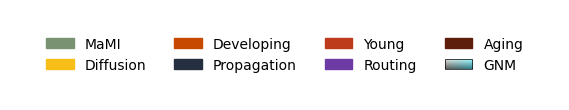

In [5]:
datasets_to_look_at = [
    'suarez_MaMI_dataset', 
    'kaysons_generated_networks_diffusion', 
    'lexis_data_developing', 
    'kaysons_generated_networks_propagation', 
    'lexis_data_young', 
    'kaysons_generated_networks_routing', 
    'lexis_data_aging',     
]

# # Build handles/labels without any axes
# handles = []
# for dataset_name in datasets_to_look_at:
#     handles.append(
#         plt.Line2D([0], [0], color=COLOR_SCHEME[dataset_name], label=LABEL_MAP[dataset_name])
#     )

# fig, ax = plt.subplots(figsize=viz.cm_to_inch((18, 3)))
# legend = ax.legend(handles=handles, ncol=4, loc="center")
# ax.axis("off")                          # hide axes entirely

# # Crop figure to the legend bounding box only
# fig.canvas.draw()
# bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
# fig.savefig(output_folder / "metastability_repertoire_sweep_legend.pdf",
#             bbox_inches=bbox, dpi=300)
# plt.show()

import matplotlib.patches as mpatches

handles = []
for dataset_name in datasets_to_look_at:
    handles.append(
        mpatches.Patch(color=COLOR_SCHEME[dataset_name], label=LABEL_MAP[dataset_name])
    )



gnm_patch = mpatches.Patch(label="GNM")

handles = []
for dataset_name in datasets_to_look_at:
    handles.append(
        mpatches.Patch(color=COLOR_SCHEME[dataset_name], label=LABEL_MAP[dataset_name])
    )
handles.append(gnm_patch)

handler_map = {gnm_patch: HandlerGradient(img)}

fig, ax = plt.subplots(figsize=viz.cm_to_inch((18, 3)))
legend = ax.legend(
    handles=handles,
    ncol=4,
    loc="center",
    frameon=False,
    handler_map=handler_map,
)
ax.axis("off")

fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(output_folder / "legend_with_aging_and_young.pdf",
            bbox_inches=bbox, dpi=300)
print(output_folder / "legend_with_aging_and_young.pdf")
plt.show()



# fig, ax = plt.subplots(figsize=viz.cm_to_inch((18, 3)))
# legend = ax.legend(handles=handles, ncol=4, loc="center", frameon=False)
# ax.axis("off")

# fig.canvas.draw()
# bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
# fig.savefig(output_folder / "metastability_repertoire_sweep_legend.pdf",
#             bbox_inches=bbox, dpi=300)
# plt.show()

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/legend_with_developing.pdf


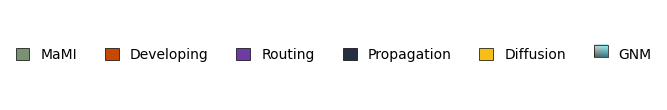

In [6]:
datasets_to_look_at = [
    'suarez_MaMI_dataset', 
    'lexis_data_developing', 
    'kaysons_generated_networks_routing', 
    'kaysons_generated_networks_propagation',
    'kaysons_generated_networks_diffusion', 
    # 'lexis_data_young', 
    # 'lexis_data_aging',     
]

import matplotlib.patches as mpatches

handles = []
for dataset_name in datasets_to_look_at:
    handles.append(
        # mpatches.Patch(color=COLOR_SCHEME[dataset_name], 
        #                label=LABEL_MAP[dataset_name],
        #                edgecolor="black", 
        #                linewidth=0.5)
        mpatches.Patch(facecolor=COLOR_SCHEME[dataset_name], 
               label=LABEL_MAP[dataset_name],
               edgecolor="black", 
               linewidth=0.5)
    )
handles.append(gnm_patch)

handler_map = {gnm_patch: HandlerGradient(img)}

fig, ax = plt.subplots(figsize=viz.cm_to_inch((18, 3)))

legend = ax.legend(handles=handles, ncol=6, loc="center", frameon=False, handler_map={gnm_patch: HandlerGradient(pixels)}, handlelength=1, handleheight=1)
ax.axis("off")

fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(output_folder / "legend_with_developing.pdf",
            bbox_inches=bbox, dpi=300)
print(output_folder / "legend_with_developing.pdf")
plt.show()


/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/trade_off_analysis/04_metastability/legend_with_developing_short.pdf


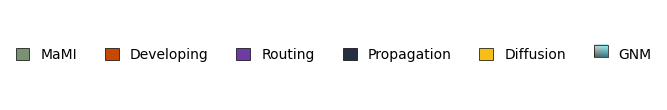

In [10]:
datasets_to_look_at = [
    'suarez_MaMI_dataset', 
    'lexis_data_developing', 
    'kaysons_generated_networks_routing', 
    'kaysons_generated_networks_propagation',
    'kaysons_generated_networks_diffusion', 
    # 'lexis_data_young', 
    # 'lexis_data_aging',     
]

import matplotlib.patches as mpatches

handles = []
for dataset_name in datasets_to_look_at:
    handles.append(
        # mpatches.Patch(color=COLOR_SCHEME[dataset_name], 
        #                label=LABEL_MAP[dataset_name],
        #                edgecolor="black", 
        #                linewidth=0.5)
        mpatches.Patch(facecolor=COLOR_SCHEME[dataset_name], 
               label=LABEL_MAP[dataset_name],
               edgecolor="black", 
               linewidth=0.5)
    )
handles.append(gnm_patch)

handler_map = {gnm_patch: HandlerGradient(img)}

fig, ax = plt.subplots(figsize=viz.cm_to_inch((12, 3)))

legend = ax.legend(handles=handles, ncol=6, loc="center", frameon=False, handler_map={gnm_patch: HandlerGradient(pixels)}, handlelength=1, handleheight=1)
ax.axis("off")

fig.canvas.draw()
bbox = legend.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
fig.savefig(output_folder / "legend_with_developing_short.pdf",
            bbox_inches=bbox, dpi=300)
print(output_folder / "legend_with_developing_short.pdf")
plt.show()


In [7]:
#F7BE18 (muted yellow) 
#799372 (muted light green) 

#262F3F (muted dark blue) 
#8F443D (muted dark red) 

#E5E4E4 (light gray)
#6E3AA3 (purple)